# Experiment 1 — Attribute Inference: the Second Leakage Axis

A record counted as **re-identification-protected** can still leak demographic
attributes. This notebook plots attribute-inference accuracy (sex; age on
ECG-ID) against the privacy budget ε, next to the re-identification curve, to
test the entanglement thesis: a *second* L-shaped leakage that falls **slower**
than re-ID, so the ε that suppresses identity does not suppress demographics.

Discipline (identical to the re-ID experiment): same three mechanisms, same
ε grid, same three seeds; individual runs drawn as faint points, mean ± std
reported; the **chance floor** is the test-set majority-class rate (not 1/n);
the **no-privacy anchor** is attribute accuracy on the unprotected signal.

Honest caveat baked into the protocol: evaluation is **subject-disjoint** (no
subject in train and test), so this measures attribute leakage and not disguised
re-identification. MIT-BIH runs sex only (47 subjects, age too thin/skewed);
ECG-ID runs sex and 2 age bands (median split).

Reads `results/attr/<dataset>/<attribute>/...` from `scripts/train_attribute.py`.


In [1]:
import os, pickle, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'savefig.bbox': 'tight',
})
RESULTS = Path(os.environ.get('EXP_NB_RESULTS', '../results'))
FIGURES = Path(os.environ.get('EXP_NB_FIGURES', RESULTS / 'figures'))
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {'laplace': 'Laplace', 'laplace_bounded': 'Bounded Laplace',
               'gaussian_analytic': 'Analytic Gaussian'}
MECH_MARKERS = {'laplace': 'o', 'laplace_bounded': 's', 'gaussian_analytic': '^'}
MECH_COLORS = {'laplace': '#1f77b4', 'laplace_bounded': '#ff7f0e',
               'gaussian_analytic': '#2ca02c'}
EPS_DELTA_RE = re.compile(r'eps_([0-9.eE+-]+)_delta_([0-9.eE+-]+)')

ATTR_ROOT = RESULTS / 'attr'

def load_attr_sweep(attr_root: Path) -> pd.DataFrame:
    rows = []
    if not attr_root.exists():
        return pd.DataFrame()
    for ds_dir in sorted(attr_root.iterdir()):
        if not ds_dir.is_dir():
            continue
        for at_dir in sorted(ds_dir.iterdir()):
            dp = at_dir / 'dp'
            if not dp.is_dir():
                continue
            for mech_dir in sorted(dp.iterdir()):
                for run_dir in sorted(mech_dir.iterdir()):
                    m = EPS_DELTA_RE.match(run_dir.name)
                    if not m:
                        continue
                    for tm_dir in sorted(run_dir.iterdir()):
                        for seed_dir in sorted(tm_dir.glob('seed_*')):
                            mp = seed_dir / 'metrics.pkl'
                            if not mp.exists():
                                continue
                            try:
                                r = pickle.load(open(mp, 'rb'))
                            except Exception:
                                continue
                            rows.append({
                                'dataset': ds_dir.name, 'attribute': at_dir.name,
                                'mechanism': mech_dir.name,
                                'eps': float(m.group(1)), 'delta': float(m.group(2)),
                                'threat_model': tm_dir.name,
                                'seed': int(seed_dir.name.split('_')[1]),
                                'window_acc': r.get('window_accuracy'),
                                'subject_acc': r.get('subject_accuracy'),
                                'floor': r.get('majority_floor'),
                            })
    return pd.DataFrame(rows)

def load_attr_baseline(attr_root: Path) -> pd.DataFrame:
    rows = []
    if not attr_root.exists():
        return pd.DataFrame()
    for ds_dir in sorted(attr_root.iterdir()):
        for at_dir in sorted(ds_dir.iterdir()):
            bdir = at_dir / 'baseline'
            if not bdir.is_dir():
                continue
            for f in sorted(bdir.glob('seed_*.pkl')):
                try:
                    r = pickle.load(open(f, 'rb'))
                except Exception:
                    continue
                rows.append({'dataset': ds_dir.name, 'attribute': at_dir.name,
                             'seed': int(f.stem.split('_')[1]),
                             'window_acc': r.get('window_accuracy'),
                             'subject_acc': r.get('subject_accuracy'),
                             'floor': r.get('majority_floor')})
    return pd.DataFrame(rows)

attr = load_attr_sweep(ATTR_ROOT)
attr_base = load_attr_baseline(ATTR_ROOT)
print('attribute sweep rows:', len(attr))
if not attr.empty:
    print(attr.groupby(['dataset','attribute','threat_model']).size())
else:
    print('No attribute results yet. Run: bash run_attribute_inference.sh')


attribute sweep rows: 459
dataset  attribute  threat_model     
ecgid    age        adaptive_attacker    153
         sex        adaptive_attacker    153
mitbih   sex        adaptive_attacker    153
dtype: int64


## Figure A — Attribute accuracy vs ε (parallel to the re-ID figure)

The attribute is constant per subject, so the honest metric is **subject-level**
(the model's per-window softmax averaged over each held-out subject, then
argmax). That is the bold curve here; window-level accuracy is drawn faint for
context. Faint points are individual seeds; the dashed grey line is the
majority-class floor; the dotted line is the no-privacy anchor — the attacker's
ceiling. **Read the anchor first:** if it sits on the floor (e.g. age), the
attacker learns nothing even without privacy, so the ε-curve carries no signal.

Saved: ../results/figures/attribute_leakage_curves.png


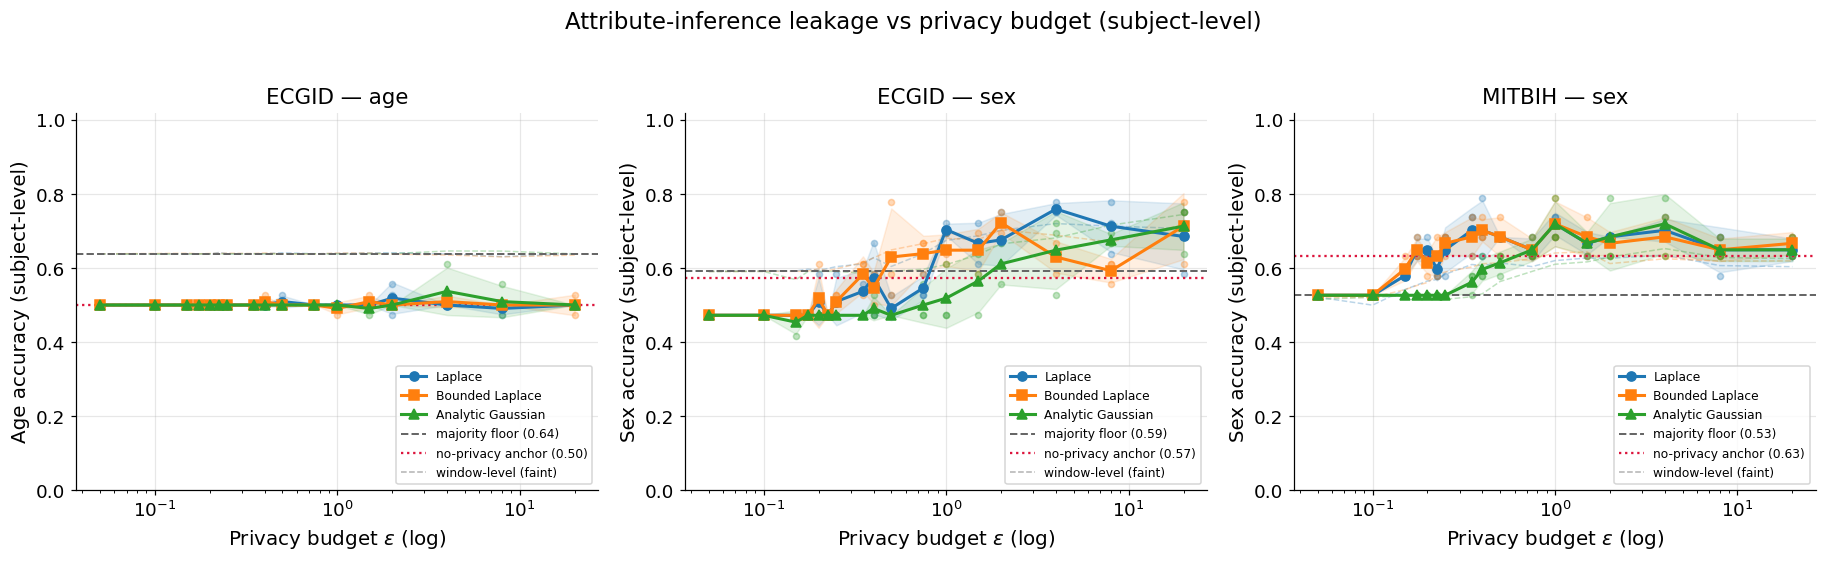

In [2]:
THREAT = 'adaptive_attacker'
HEADLINE_METRIC = 'subject_acc'    # per-subject attribute -> subject-level is honest
SECONDARY_METRIC = 'window_acc'    # shown faint for context

def panels(attr, attr_base):
    if attr.empty:
        return []
    keys = (attr[attr['threat_model'] == THREAT][['dataset','attribute']]
            .drop_duplicates().sort_values(['dataset','attribute'])
            .itertuples(index=False))
    return list(keys)

def plot_attr_curves(attr, attr_base, metric=HEADLINE_METRIC,
                     secondary=SECONDARY_METRIC, save=None):
    keys = panels(attr, attr_base)
    if not keys:
        print('No data to plot yet.'); return
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(5.6*n, 5.0), squeeze=False)
    axes = axes[0]
    for ax, (ds, at) in zip(axes, keys):
        sub = attr[(attr['dataset']==ds)&(attr['attribute']==at)&(attr['threat_model']==THREAT)]
        for mech in MECH_LABELS:
            s = sub[sub['mechanism']==mech]
            if s.empty:
                continue
            col = MECH_COLORS[mech]
            # window-level: faint thin line for context
            gw = s.groupby('eps')[secondary].mean().reset_index().sort_values('eps')
            ax.plot(gw['eps'], gw[secondary], '--', color=col, lw=1, alpha=0.30, zorder=1)
            # subject-level: headline (seed scatter + mean + std band)
            ax.scatter(s['eps'], s[metric], s=16, color=col, alpha=0.30, zorder=2)
            g = s.groupby('eps')[metric].agg(['mean','std']).reset_index().sort_values('eps')
            ax.plot(g['eps'], g['mean'], '-', color=col, marker=MECH_MARKERS[mech],
                    lw=2, ms=6, zorder=3, label=MECH_LABELS[mech])
            ax.fill_between(g['eps'], g['mean']-g['std'].fillna(0),
                            g['mean']+g['std'].fillna(0), color=col, alpha=0.12, zorder=1)
        fl = sub['floor'].dropna().mean() if not sub.empty else np.nan
        if not np.isnan(fl):
            ax.axhline(fl, color='0.4', ls='--', lw=1.3, label=f'majority floor ({fl:.2f})')
        b = attr_base[(attr_base['dataset']==ds)&(attr_base['attribute']==at)]
        if not b.empty and metric in b:
            anch = b[metric].mean()
            ax.axhline(anch, color='crimson', ls=':', lw=1.5,
                       label=f'no-privacy anchor ({anch:.2f})')
        ax.plot([], [], '--', color='0.5', lw=1, alpha=0.6, label='window-level (faint)')
        ax.set_xscale('log')
        ax.set_xlabel(r'Privacy budget $\varepsilon$ (log)')
        ax.set_ylabel(f'{at.capitalize()} accuracy (subject-level)')
        ax.set_ylim(0, 1.02)
        ax.set_title(f'{ds.upper()} — {at}')
        ax.legend(fontsize=8.0, loc='lower right')
    fig.suptitle('Attribute-inference leakage vs privacy budget (subject-level)',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); print('Saved:', save)
    plt.show()

plot_attr_curves(attr, attr_base, save=FIGURES / 'attribute_leakage_curves.png')


## Figure B — Two leakage axes side by side

Per corpus: the re-identification curve (adaptive attacker, window-level) against
the attribute-inference curve (subject-level), each with its own chance floor.
The entanglement reading is conditional and must be stated honestly: it holds
only to the extent the attribute's **no-privacy anchor clears its floor** (Figure
A). Where it does (sex), compare how far identity falls with ε against how far
demographics fall — the claim is "demographics fall slower / persist", not
"demographics are highly accurate". Where the anchor is at the floor (age), the
flat curve reflects an unlearnable attribute, not protected leakage.

Saved: ../results/figures/attribute_vs_reid_leakage.png


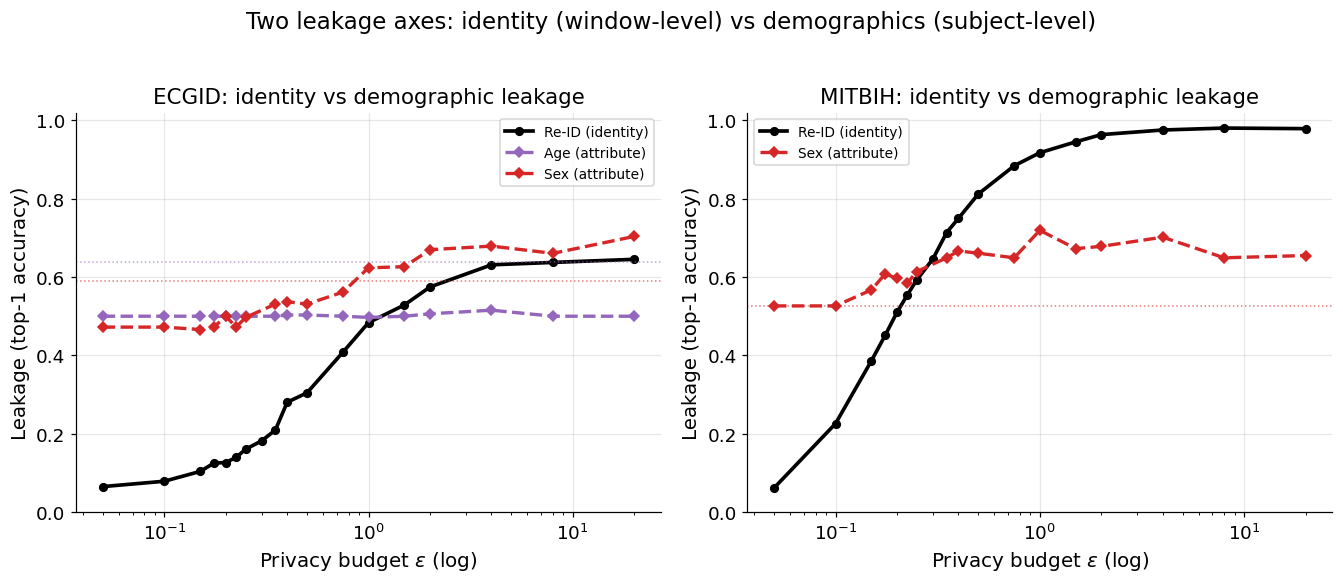

In [3]:
from _loader import load_reid_sweep

def reid_adaptive_curve(reid_dir):
    df = load_reid_sweep(reid_dir)
    if df.empty:
        return pd.DataFrame()
    d = df[df['threat_model']=='adaptive_attacker']
    return (d.groupby('eps')['reid_accuracy'].agg(['mean','std']).reset_index()
            .sort_values('eps'))

REID_DIRS = {'mitbih': RESULTS/'reid', 'ecgid': RESULTS/'reid_ecgid'}

def plot_side_by_side(attr, save=None):
    if attr.empty:
        print('No attribute data yet.'); return
    dss = sorted(attr['dataset'].unique())
    fig, axes = plt.subplots(1, len(dss), figsize=(6.2*len(dss), 5.2), squeeze=False)
    axes = axes[0]
    for ax, ds in zip(axes, dss):
        # re-ID (identity leakage), mechanism-averaged for a clean reference
        rc = reid_adaptive_curve(REID_DIRS.get(ds, RESULTS/'reid'))
        if not rc.empty:
            ax.plot(rc['eps'], rc['mean'], '-', color='black', lw=2.4, marker='o',
                    ms=5, label='Re-ID (identity)')
        # attribute curves (mechanism-averaged)
        sub = attr[(attr['dataset']==ds)&(attr['threat_model']==THREAT)]
        palette = {'sex': '#d62728', 'age': '#9467bd'}
        for at in sorted(sub['attribute'].unique()):
            s = sub[sub['attribute']==at]
            g = s.groupby('eps')[HEADLINE_METRIC].mean().reset_index().sort_values('eps')
            ax.plot(g['eps'], g[HEADLINE_METRIC], '--', color=palette.get(at,'#9467bd'),
                    lw=2.2, marker='D', ms=5, label=f'{at.capitalize()} (attribute)')
            fl = s['floor'].dropna().mean()
            if not np.isnan(fl):
                ax.axhline(fl, color=palette.get(at,'#9467bd'), ls=':', lw=1, alpha=0.6)
        ax.set_xscale('log')
        ax.set_xlabel(r'Privacy budget $\varepsilon$ (log)')
        ax.set_ylabel('Leakage (top-1 accuracy)')
        ax.set_ylim(0, 1.02)
        ax.set_title(f'{ds.upper()}: identity vs demographic leakage')
        ax.legend(fontsize=9, loc='best')
    fig.suptitle('Two leakage axes: identity (window-level) vs demographics (subject-level)',
                 fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300); print('Saved:', save)
    plt.show()

plot_side_by_side(attr, save=FIGURES / 'attribute_vs_reid_leakage.png')


## Quantitative summary + CSV + takeaway

In [4]:
def attr_summary(attr, attr_base):
    if attr.empty:
        print('No data.'); return pd.DataFrame()
    g = (attr[attr['threat_model']==THREAT]
         .groupby(['dataset','attribute','mechanism','eps'])
         .agg(subject_acc=('subject_acc','mean'), subject_std=('subject_acc','std'),
              window_acc=('window_acc','mean'), floor=('floor','mean'))
         .reset_index())
    return g

def anchor_table(attr_base):
    '''No-privacy anchor (subject-level) vs floor per (dataset, attribute).'''
    if attr_base.empty:
        return pd.DataFrame()
    return (attr_base.groupby(['dataset','attribute'])
            .agg(anchor_subject=('subject_acc','mean'),
                 anchor_window=('window_acc','mean'),
                 floor=('floor','mean')).reset_index())

summary = attr_summary(attr, attr_base)
anchors = anchor_table(attr_base)
if not anchors.empty:
    a = anchors.copy(); a['anchor_above_floor'] = a['anchor_subject'] - a['floor']
    print('No-privacy anchor (the attacker ceiling) vs chance floor:')
    print(a.round(3).to_string(index=False))
    print('  -> anchor at/near floor = attribute not learnable here (e.g. age);')
    print('     anchor clearly above floor = a real, if modest, leakage channel.\n')
if not summary.empty:
    show = summary.copy()
    show['above_floor'] = show['subject_acc'] - show['floor']
    print(show.round(3).to_string(index=False))
    out = RESULTS / 'attribute_leakage_summary.csv'
    summary.round(5).to_csv(out, index=False); print('\nSaved:', out)

def takeaway(summary, anchors):
    if summary.empty:
        return 'No results yet. Run bash run_attribute_inference.sh.'
    amap = {(r.dataset, r.attribute): (r.anchor_subject, r.floor)
            for r in anchors.itertuples()} if not anchors.empty else {}
    lines = []
    for (ds, at), s in summary.groupby(['dataset','attribute']):
        anch, fl = amap.get((ds, at), (float('nan'), s['floor'].mean()))
        if not (anch != anch) and anch - fl < 0.03:
            lines.append(f'{ds.upper()}/{at}: no-privacy anchor {anch:.2f} ~ floor '
                         f'{fl:.2f} -> attribute NOT learnable here; the flat ε-curve '
                         f'is a feasibility limit, not protected leakage.')
            continue
        lo = s[s['eps'] <= 0.25]; ref = lo if not lo.empty else s
        acc = ref['subject_acc'].mean()
        lines.append(f'{ds.upper()}/{at}: anchor {anch:.2f} vs floor {fl:.2f}; at low '
                     f'eps (<=0.25) subject-level ~{acc:.2f} (+{acc-fl:.2f} above floor).')
    return '\n'.join(lines)

print('\n' + takeaway(summary, anchors))


No-privacy anchor (the attacker ceiling) vs chance floor:
dataset attribute  anchor_subject  anchor_window  floor  anchor_above_floor
  ecgid       age           0.500          0.638  0.638              -0.138
  ecgid       sex           0.574          0.678  0.591              -0.016
 mitbih       sex           0.632          0.616  0.526               0.105
  -> anchor at/near floor = attribute not learnable here (e.g. age);
     anchor clearly above floor = a real, if modest, leakage channel.

dataset attribute         mechanism    eps  subject_acc  subject_std  window_acc  floor  above_floor
  ecgid       age gaussian_analytic  0.050        0.500        0.000       0.638  0.638       -0.138
  ecgid       age gaussian_analytic  0.100        0.500        0.000       0.638  0.638       -0.138
  ecgid       age gaussian_analytic  0.150        0.500        0.000       0.638  0.638       -0.138
  ecgid       age gaussian_analytic  0.175        0.500        0.000       0.638  0.638       